Neste notebook estarei implementando um autoencoder que ira codificar a imagem nas camadas ocultas, compactando-a, e depois a imagems será posteriormente descompactada para testar o erro da rede.

A rede ira receber imagens do dataset MNIST, irá aprender a codificar as imagens compactuando-as em suas camadas ocultas, e irá aprender a decodificar elas em sua camada de saída.

Posteriormente a rede será dividida em duas com seus respectivos pesos e biases aprendidos:

A parte codificadora, e a parte decodificadora.

In [2]:
from torchvision import datasets
import torch
import torchvision.transforms as T
from torch import nn, optim
import matplotlib.pyplot as plt

torch.manual_seed(123)

Criação da base de dados:

In [3]:
dataset_train = datasets.MNIST('../', train = True, download = True, transform = T.ToTensor())
loader_train = torch.utils.data.DataLoader(dataset_train, batch_size = 128, shuffle = True)

In [4]:
dataset_test = datasets.MNIST('../', train = False, download = True, transform = T.ToTensor())
loader_test = torch.utils.data.DataLoader(dataset_train, batch_size = 128, shuffle = True)

Construção do modelo:

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

Na ultima camada é aplicado a fç de ativação sigmoid, pois ela converterá cada um dos 28*28 neuronios para valores entre 0 e 1, que é a mesma escala normalizada do tensor de entrada (Já que ele sofreu transformações na hora da criação do dataset).

Isso é feito pois o erro deve ser calculado considerando o valor de cada pixel de saída em comparação com cada pixel de entrada e para isso, os dois precisam estar na mesma escala.

In [6]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(nn.Flatten(),
                                   # Codificador
                                   nn.Linear(28*28, 32),
                                   nn.ReLU(),
                                   # Decodificador
                                   nn.Linear(32, 28*28),
                                   nn.Sigmoid())
    def forward(self, X):
        return self.model(X)

    def testaFlatten(self, X):
        X_flat = self.model[0](X)
        return X_flat.shape
    
    

In [7]:
model = Autoencoder().to(device)

In [8]:
model.eval()

it = iter(loader_train)
X1, _ = next(it)

print("Shape antes do flatten:" + str(X1.shape))
print("Shape caso faça .view: " + str(X1.view(-1, 28*28).shape))
with torch.no_grad():
    x1_flat_shape = model.testaFlatten(X1.to(device))
    print(f"Shape caso faça flatten na 1a camda: {x1_flat_shape}")

Shape antes do flatten:torch.Size([128, 1, 28, 28])
Shape caso faça .view: torch.Size([128, 784])
Shape caso faça flatten na 1a camda: torch.Size([128, 784])


De acordo com a execução acima, conclui-se que fazer nn.Flatten() na primeira camada, é equivalente a fazer X = X.view(-1, 28*28) antes do forward.

BCELoss compara predições e alvos em escala entre 0 e 1.

In [9]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters())

Treinamento do modelo junto com o teste em cada epoch:

In [10]:
for epoch in range(20):
    # Treinamento
    total_loss_train = 0.0
    model.train()

    for inputs, _ in loader_train:
        inputs = inputs.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        targets = inputs.view(*outputs.shape)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()
    
    # Teste
    total_loss_val = 0.0
    model.eval()

    with torch.no_grad():
        for inputs, _ in loader_test:
            inputs = inputs.to(device)
            outputs = model(inputs)

            targets = inputs.view(*outputs.shape)
            loss = criterion(outputs, targets)
            
            total_loss_val += loss.item()
        
    # Final da época
    print('ÉPOCA {:3d}: perda_train {:.5f} perda_val {:.5f}'.format(epoch + 1, total_loss_train/len(loader_train), total_loss_val/len(loader_test)))

ÉPOCA   1: perda_train 0.23941 perda_val 0.16962
ÉPOCA   2: perda_train 0.15137 perda_val 0.13847
ÉPOCA   3: perda_train 0.13117 perda_val 0.12492
ÉPOCA   4: perda_train 0.12080 perda_val 0.11704
ÉPOCA   5: perda_train 0.11457 perda_val 0.11241
ÉPOCA   6: perda_train 0.11099 perda_val 0.10989
ÉPOCA   7: perda_train 0.10907 perda_val 0.10830
ÉPOCA   8: perda_train 0.10806 perda_val 0.10764
ÉPOCA   9: perda_train 0.10675 perda_val 0.10550
ÉPOCA  10: perda_train 0.10534 perda_val 0.10511
ÉPOCA  11: perda_train 0.10497 perda_val 0.10471
ÉPOCA  12: perda_train 0.10476 perda_val 0.10460
ÉPOCA  13: perda_train 0.10461 perda_val 0.10444
ÉPOCA  14: perda_train 0.10448 perda_val 0.10432
ÉPOCA  15: perda_train 0.10439 perda_val 0.10431
ÉPOCA  16: perda_train 0.10433 perda_val 0.10421
ÉPOCA  17: perda_train 0.10425 perda_val 0.10409
ÉPOCA  18: perda_train 0.10419 perda_val 0.10410
ÉPOCA  19: perda_train 0.10413 perda_val 0.10398
ÉPOCA  20: perda_train 0.10410 perda_val 0.10389


Criação do encoder com base no autoencoder:

In [11]:
list(model.children())

[Sequential(
   (0): Flatten(start_dim=1, end_dim=-1)
   (1): Linear(in_features=784, out_features=32, bias=True)
   (2): ReLU()
   (3): Linear(in_features=32, out_features=784, bias=True)
   (4): Sigmoid()
 )]

In [12]:
list(model.children())[0]

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=32, bias=True)
  (2): ReLU()
  (3): Linear(in_features=32, out_features=784, bias=True)
  (4): Sigmoid()
)

In [13]:
list(model.children())[0][0]

Flatten(start_dim=1, end_dim=-1)

In [14]:
class Encoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        # Apenas camadas (0), (1) e (2) do Autoencoder.
        self.model = nn.Sequential(*list(autoencoder.children())[0][:3])

    def forward(self, X):
        return self.model(X)

In [15]:
encoder = Encoder(model)
encoder.to(device)

Encoder(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=32, bias=True)
    (2): ReLU()
  )
)

Criação do decoder com base no autoencoder:

In [16]:
class Decoder(nn.Module):
    def __init__(self, autoencoder):
        super().__init__()
        # Apenas camadas (3) e (4) do Autoencoder.
        self.model = nn.Sequential(*list(autoencoder.children())[0][3:])

    def forward(self, X):
        return self.model(X)

In [17]:
decoder = Decoder(model)
decoder.to(device)

Decoder(
  (model): Sequential(
    (0): Linear(in_features=32, out_features=784, bias=True)
    (1): Sigmoid()
  )
)

Visualização dos resultados:

In [18]:
numero_imagens = 20
# Pega 20 imagens do batch 0
imagens_teste = (next(iter(loader_test))[0][:numero_imagens]).to(device)
imagens_teste, imagens_teste.shape

(tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         ...,
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ..

Codificação das imagens:

In [19]:
encoder.eval()
imagens_codificadas = encoder(imagens_teste)
imagens_codificadas, imagens_codificadas.shape

(tensor([[ 8.8131,  5.9654,  0.0000, 10.9519,  0.0000, 13.2614,  0.0000,  8.5281,
          18.0542, 15.3409,  0.0000,  5.2763,  9.3654, 10.7981, 15.0291,  8.7750,
           7.5163,  0.0000,  4.4210,  6.2560,  6.7139,  0.0000,  7.8766,  0.0000,
           5.2925, 12.9254, 15.8431,  0.0000, 10.8867,  3.1833, 14.9351, 16.0308],
         [ 9.0621, 13.1584, 11.2629,  8.6950,  0.0000, 21.1597,  0.0000,  7.0323,
          12.4778,  2.2519,  0.0000, 11.6356,  6.5043, 11.2503,  9.6993,  8.9408,
          11.1575,  0.0000, 14.1798,  9.2569,  4.8430,  0.0000,  7.1926,  0.0000,
           5.1311, 11.2573, 15.5389,  0.0000, 11.9294,  3.9744, 12.2148, 13.1726],
         [14.0796,  6.2251, 10.5894,  8.6387,  0.0000,  8.1081,  0.0000,  9.1750,
           7.4376,  6.7488,  0.0000,  7.9355,  6.2842, 12.9811,  4.0105,  7.8858,
           2.9803,  0.0000, 13.4985, 12.8091,  2.3744,  0.0000,  5.1355,  0.0000,
           8.5642,  2.8090,  6.5763,  0.0000, 12.4907,  3.9761, 19.5565, 10.6584],
         [10.

Decodificação das imagens:

In [20]:
decoder.eval()
imagens_decodificadas = decoder(imagens_codificadas)
imagens_decodificadas, imagens_decodificadas.shape

(tensor([[6.5868e-16, 1.6161e-17, 3.3194e-14,  ..., 8.5407e-16, 6.1398e-16,
          5.3178e-15],
         [1.4262e-16, 2.4828e-16, 2.1843e-16,  ..., 1.0350e-14, 3.0659e-16,
          7.6587e-16],
         [7.1331e-15, 4.8541e-13, 3.9126e-13,  ..., 1.5139e-12, 5.0903e-12,
          2.7249e-13],
         ...,
         [2.8566e-09, 5.1152e-10, 1.5327e-08,  ..., 5.0723e-09, 3.5659e-10,
          1.1250e-08],
         [3.7792e-13, 2.2820e-14, 7.1081e-13,  ..., 4.3980e-13, 6.2251e-14,
          9.2626e-14],
         [3.8545e-13, 1.0965e-13, 1.6328e-13,  ..., 1.1153e-12, 8.9119e-14,
          6.7144e-14]], device='cuda:0', grad_fn=<SigmoidBackward0>),
 torch.Size([20, 784]))

In [21]:
imagens_decodificadas.view(-1, 28, 28).shape

torch.Size([20, 28, 28])

In [37]:
imagens_teste_plt = imagens_teste.view(-1, 28, 28).detach().cpu().numpy()
imagens_teste_plt.shape

(20, 28, 28)

In [40]:
imagens_codificadas_plt = imagens_codificadas.view(-1, 8, 4).detach().cpu().numpy()
imagens_codificadas_plt, imagens_codificadas_plt.shape

(array([[[ 8.8131485 ,  5.9653983 ,  0.        , 10.951866  ],
         [ 0.        , 13.261418  ,  0.        ,  8.528131  ],
         [18.05417   , 15.340945  ,  0.        ,  5.2763033 ],
         [ 9.365408  , 10.798126  , 15.029074  ,  8.774992  ],
         [ 7.51628   ,  0.        ,  4.420974  ,  6.2560325 ],
         [ 6.7139177 ,  0.        ,  7.8766146 ,  0.        ],
         [ 5.292486  , 12.925427  , 15.8431425 ,  0.        ],
         [10.886674  ,  3.183314  , 14.935081  , 16.0308    ]],
 
        [[ 9.062107  , 13.158371  , 11.262893  ,  8.695045  ],
         [ 0.        , 21.159748  ,  0.        ,  7.032261  ],
         [12.477806  ,  2.251923  ,  0.        , 11.635563  ],
         [ 6.504281  , 11.250254  ,  9.699291  ,  8.940756  ],
         [11.157546  ,  0.        , 14.179824  ,  9.256874  ],
         [ 4.843046  ,  0.        ,  7.192581  ,  0.        ],
         [ 5.1311235 , 11.257273  , 15.538946  ,  0.        ],
         [11.929359  ,  3.9744217 , 12.214756  , 13.

In [27]:
imagens_decodificadas_plt = imagens_decodificadas.view(-1, 28, 28).detach().cpu().numpy()
imagens_decodificadas_plt.shape

(20, 28, 28)

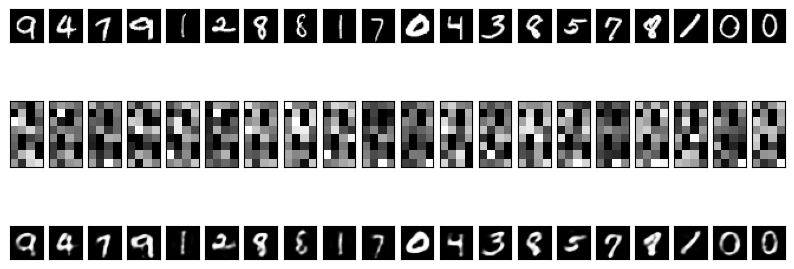

In [42]:
fig, axes = plt.subplots(nrows = 3, ncols = numero_imagens, figsize = (10, 4))
for imagens, ax_row in zip([imagens_teste_plt, imagens_codificadas_plt, imagens_decodificadas_plt], axes):
    for img, ax in zip(imagens, ax_row):
        ax.imshow(img, cmap = 'gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)